# BAER Reference Data — dNBR & RdNBR Plots

Visualizes dNBR and RdNBR rasters from the BAER reference dataset for all 10 available fires.

**Environment:** `burnseverity` conda environment — same as all other notebooks in this repo.

```bash
conda activate burnseverity
```

**Data:** `baer/organized/<FIRE_NAME>/` — each subdirectory contains BAER-derived GeoTIFFs downloaded from the USGS BAER imagery support portal. Files follow the naming convention `<fire_id>_<pre_date>_<post_date>_dnbr.tif` / `*_rdnbr.tif`. York (2023) was distributed as an SBS package with UTM-projected files (`*_dnbr_utm.tif`); it has no RdNBR product.

In [9]:
# conda activate burnseverity
import os
import glob
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

## Configuration & File Discovery

In [10]:
BAER_DIR = Path('baer/organized')

fires = {}
for fire_dir in sorted(BAER_DIR.iterdir()):
    if not fire_dir.is_dir():
        continue
    fire_name = fire_dir.name

    # dNBR: prefer exact suffix *_dnbr.tif; fall back to *_dnbr_utm.tif (YORK)
    dnbr_files = sorted(fire_dir.glob('*_dnbr.tif'))
    if not dnbr_files:
        dnbr_files = sorted(fire_dir.glob('*_dnbr_utm.tif'))
    dnbr_path = dnbr_files[0] if dnbr_files else None

    # RdNBR: exact suffix only (YORK has none)
    rdnbr_files = sorted(fire_dir.glob('*_rdnbr.tif'))
    rdnbr_path = rdnbr_files[0] if rdnbr_files else None

    fires[fire_name] = {'dnbr': dnbr_path, 'rdnbr': rdnbr_path}

for name, paths in fires.items():
    print(f"{name}")
    print(f"  dNBR : {paths['dnbr'].name if paths['dnbr'] else 'MISSING'}")
    print(f"  RdNBR: {paths['rdnbr'].name if paths['rdnbr'] else 'N/A'}")

COFFEE_POT_2024-08-03
  dNBR : ca3639211876520240803_20240729_20240914_dnbr.tif
  RdNBR: ca3639211876520240803_20240729_20240914_rdnbr.tif
DOME_2020-08-15
  dNBR : ca3530111559820200815_20200808_20200902_dnbr.tif
  RdNBR: ca3530111559820200815_20200808_20200902_rdnbr.tif
GEOLOGY_2023-06-10
  dNBR : ca3389711605420230610_20230603_20230619_dnbr.tif
  RdNBR: ca3389711605420230610_20230603_20230619_rdnbr.tif
KNP_COMPLEX_2021-09-10
  dNBR : ca3658211879520210912_20210908_20211013_dnbr.tif
  RdNBR: ca3658211879520210912_20210908_20211013_rdnbr.tif
MOJAVE_2021-06-17
  dNBR : ca3534311578320210617_20210614_20210624_dnbr.tif
  RdNBR: ca3534311578320210617_20210614_20210624_rdnbr.tif
RATTLESNAKE_2020-08-16
  dNBR : ca3642011844820200816_20191103_20201204_dnbr.tif
  RdNBR: ca3642011844820200816_20191103_20201204_rdnbr.tif
REDWOOD_2023-08-15
  dNBR : ca4131412396920230815_20230731_20230830_dnbr.tif
  RdNBR: ca4131412396920230815_20230731_20230830_rdnbr.tif
SANTA_CRUZ_2018-03-27
  dNBR : ca33996119

## Helper — Load Raster Band

In [11]:
def load_band(path):
    """Read band 1 of a GeoTIFF as a float array; nodata → NaN.

    masked=True already handles nodata masking via the file's metadata.
    .filled(np.nan) converts masked positions to NaN, giving a clean regular
    ndarray. Avoids the np.where-on-masked-array bug where raw nodata values
    (e.g. YORK's nodata=32767) leak into the array and swamp the colour scale.
    """
    with rasterio.open(path) as src:
        data = src.read(1, masked=True).astype(float)
        return data.filled(np.nan)

## Grid Plot — dNBR (col 1) and RdNBR (col 2), fires as rows

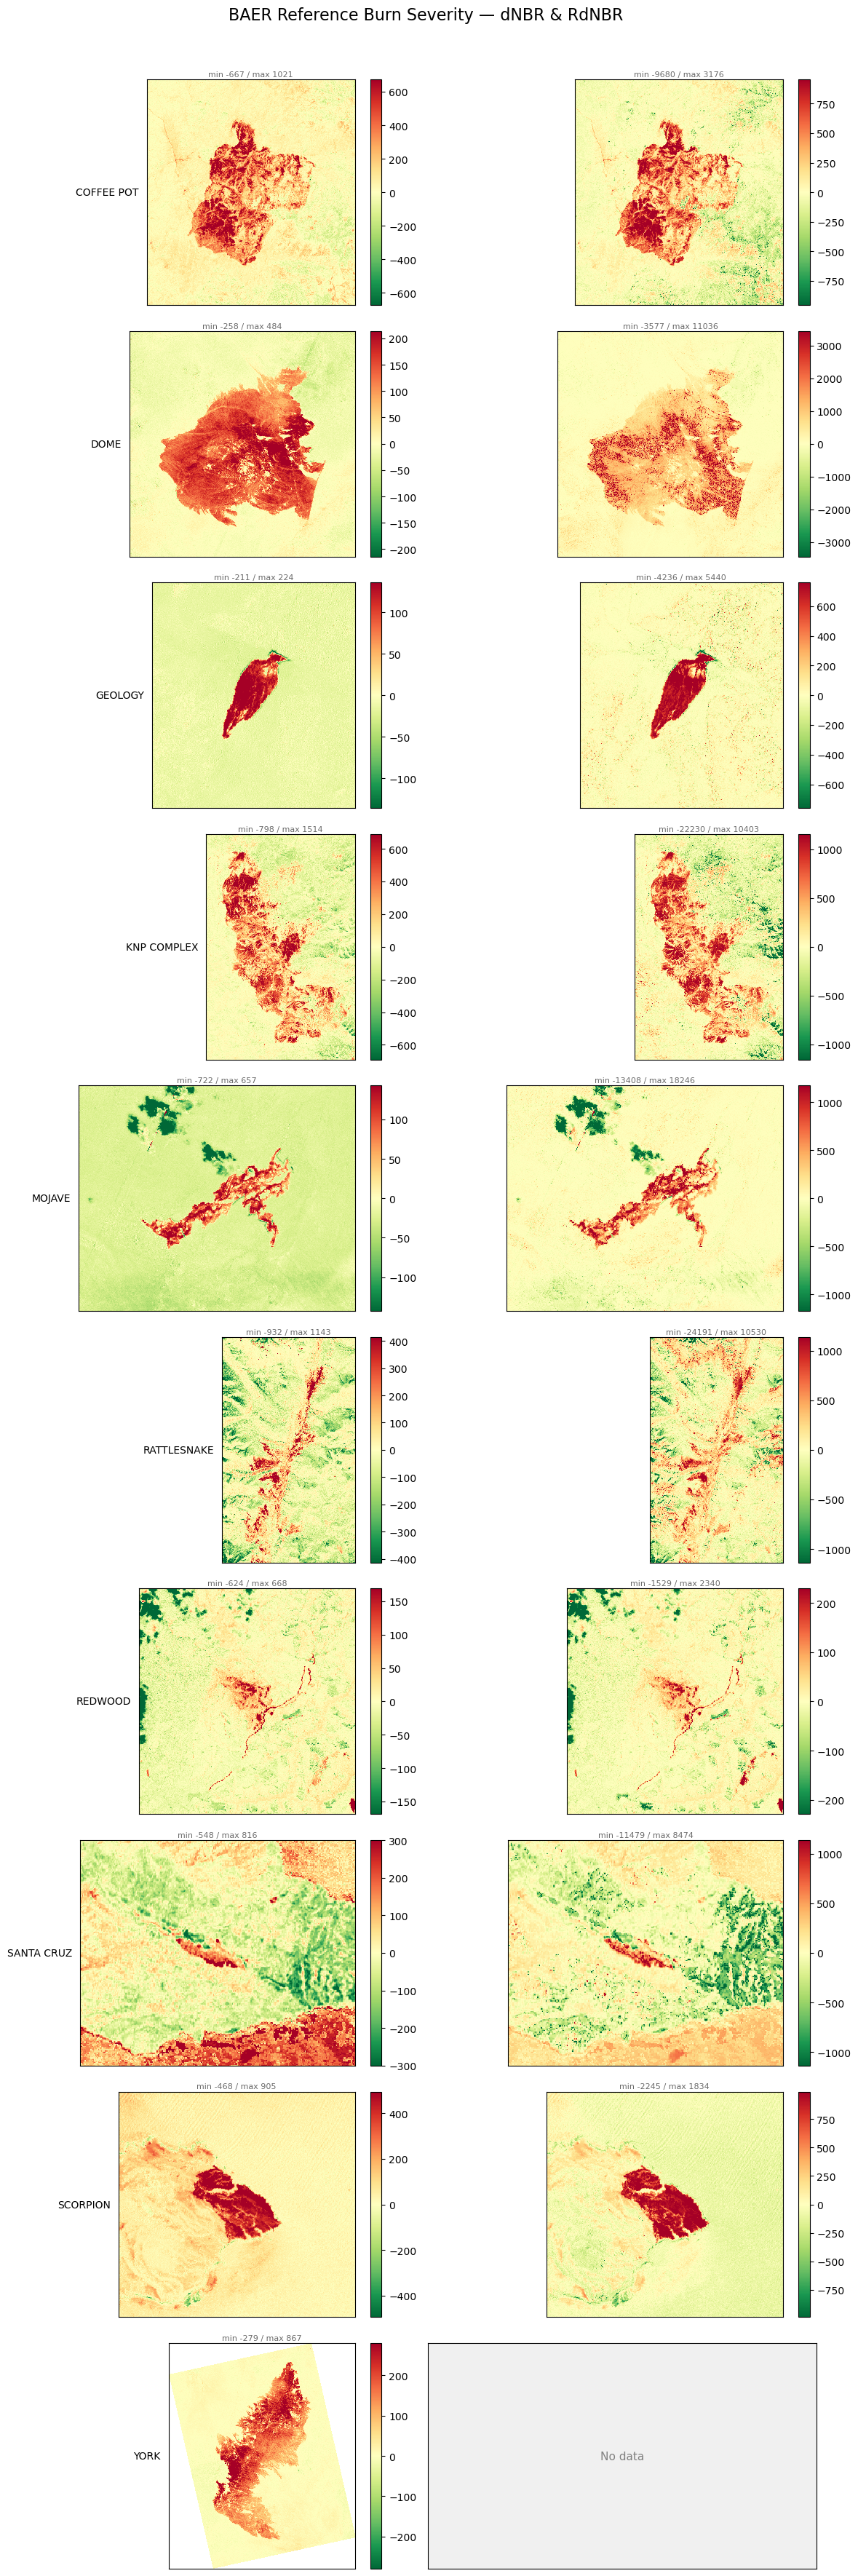

Saved → baer/baer_dnbr_rdnbr_grid.png


In [14]:
CMAP = 'RdYlGn_r'   # high burn severity → red, low → green
METRICS = ['dnbr', 'rdnbr']
COL_TITLES = ['dNBR', 'RdNBR']

fire_names = list(fires.keys())
n_fires = len(fire_names)
n_cols = len(METRICS)

fig, axes = plt.subplots(
    n_fires, n_cols,
    figsize=(6 * n_cols, 3.5 * n_fires),
    squeeze=False
)

# Column titles
for col, title in enumerate(COL_TITLES):
    axes[0, col].set_title(title, fontsize=14, fontweight='bold', pad=10)

for row, fire_name in enumerate(fire_names):
    paths = fires[fire_name]

    # Clean label: replace underscores, drop date suffix
    label = fire_name.rsplit('_', 1)[0].replace('_', ' ')

    for col, metric in enumerate(METRICS):
        ax = axes[row, col]
        path = paths[metric]

        if path is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='grey')
            ax.set_facecolor('#f0f0f0')
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            data = load_band(path)
            valid = data[np.isfinite(data)]
            vmax = np.percentile(np.abs(valid), 98) if valid.size else 1
            vmin = -vmax

            im = ax.imshow(data, cmap=CMAP, vmin=vmin, vmax=vmax, interpolation='nearest')
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.set_xticks([])
            ax.set_yticks([])
            vmin_actual, vmax_actual = np.nanmin(data), np.nanmax(data)
            ax.set_title(f'min {vmin_actual:.0f} / max {vmax_actual:.0f}', fontsize=8, color='dimgrey', pad=3)

        # Row label on the left column only
        if col == 0:
            ax.set_ylabel(label, fontsize=10, labelpad=8, rotation=0,
                          ha='right', va='center')

fig.suptitle('BAER Reference Burn Severity — dNBR & RdNBR', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('baer/baer_dnbr_rdnbr_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → baer/baer_dnbr_rdnbr_grid.png")